# House Prices - Advanced Regression Techniques

Predict the sales price for each house using 79 explanatory variables.

Metric: RMSE between log of predicted and log of observed sale price.

---
# 1. Setup & Data Loading

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE, mutual_info_regression
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb

import mlflow
import mlflow.sklearn
import dagshub

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

In [49]:
dagshub.init(repo_owner='rkvit23', repo_name='ML-HW1', mlflow=True)
mlflow.set_tracking_uri("https://dagshub.com/rkvit23/ML-HW1.mlflow")

Initialized MLflow to track repo "rkvit23/ML-HW1"

Repository rkvit23/ML-HW1 initialized!

In [50]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print(train_df.shape)
print(test_df.shape)
print(train_df.shape[1])
print(f"\nnum: {train_df.select_dtypes(include='number').shape[1]}")
print(f"cat: {train_df.select_dtypes(exclude='number').shape[1]}")
train_df.head()

(1460, 81)
(1459, 80)
81

num: 38
cat: 43


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
# 2. Cleaning

Before cleaning, we need to understand the nature of missing values in this dataset.

## 2.1 Missing Values Analysis

In [194]:
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train_df) * 100).round(2)

missing_table = pd.DataFrame({'Count': missing, 'Percent': missing_pct})
print(missing_table)



              Count  Percent
PoolQC         1452    99.59
MiscFeature    1404    96.30
Alley          1367    93.76
Fence          1177    80.73
MasVnrType      872    59.81
FireplaceQu     690    47.33
LotFrontage     259    17.76
GarageType       81     5.56
GarageYrBlt      81     5.56
GarageFinish     81     5.56
GarageQual       81     5.56
GarageCond       81     5.56
BsmtExposure     38     2.61
BsmtFinType2     38     2.61
BsmtQual         37     2.54
BsmtCond         37     2.54
BsmtFinType1     37     2.54
MasVnrArea        8     0.55
Electrical        1     0.07


## 2.2 Outlier Detection

In [197]:
outlier_mask = (train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)
outliers = train_df[outlier_mask]

In [198]:
train_df = train_df.drop(outliers.index)
print(f"Train shape after outlier removal: {train_df.shape}")

Train shape after outlier removal: (1458, 81)


## 2.3 Apply Cleaning

In [55]:
y = train_df['SalePrice'].copy()
train_ids = train_df['Id'].copy()
test_ids = test_df['Id'].copy()

X_train_raw = train_df.drop(['SalePrice', 'Id'], axis=1)
X_test_raw = test_df.drop(['Id'], axis=1)

y_log = np.log1p(y)

print(f"X_train: {X_train_raw.shape}, y: {y_log.shape}")
print(f"X_test:  {X_test_raw.shape}")

X_train: (1458, 79), y: (1458,)
X_test:  (1459, 79)


In [58]:
NA_MEANS_NONE_CAT = [
    'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType'
]

NA_MEANS_ZERO_NUM = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]


class MissingValueHandler(BaseEstimator, TransformerMixin):
    """Handles missing values with domain-aware logic for the Ames Housing dataset."""

    def __init__(self):
        self.lot_frontage_medians_ = None
        self.lot_frontage_global_median_ = None
        self.electrical_mode_ = None
        self.cat_modes_ = None
        self.num_medians_ = None

    def fit(self, X, y=None):
        self.lot_frontage_medians_ = X.groupby('Neighborhood')['LotFrontage'].median()
        self.lot_frontage_global_median_ = X['LotFrontage'].median()
        self.electrical_mode_ = X['Electrical'].mode()[0]

        cat_cols = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
        self.cat_modes_ = {}
        for c in cat_cols:
            if c not in NA_MEANS_NONE_CAT:
                self.cat_modes_[c] = X[c].mode()[0]

        num_cols = X.select_dtypes(include='number').columns
        self.num_medians_ = X[num_cols].median()
        return self

    def transform(self, X):
        X = X.copy()

        for col in NA_MEANS_NONE_CAT:
            if col in X.columns:
                X[col] = X[col].fillna('None')

        for col in NA_MEANS_ZERO_NUM:
            if col in X.columns:
                X[col] = X[col].fillna(0)

        if 'LotFrontage' in X.columns and X['LotFrontage'].isnull().any():
            X['LotFrontage'] = X.apply(
                lambda row: self.lot_frontage_medians_.get(
                    row['Neighborhood'], self.lot_frontage_global_median_)
                if pd.isnull(row['LotFrontage']) else row['LotFrontage'],
                axis=1
            )

        if 'Electrical' in X.columns:
            X['Electrical'] = X['Electrical'].fillna(self.electrical_mode_)

        for col, mode_val in self.cat_modes_.items():
            if col in X.columns:
                X[col] = X[col].fillna(mode_val)

        num_cols = X.select_dtypes(include='number').columns
        for col in num_cols:
            if X[col].isnull().any():
                fill_val = self.num_medians_.get(col, 0) if col in self.num_medians_.index else 0
                X[col] = X[col].fillna(fill_val)

        return X


mv_handler = MissingValueHandler()
mv_handler.fit(X_train_raw)

X_train_clean = mv_handler.transform(X_train_raw)
X_test_clean = mv_handler.transform(X_test_raw)

print(f"train nas: {X_train_clean.isnull().sum().sum()}")
print(f"test  nas: {X_test_clean.isnull().sum().sum()}")

train nas: 0
test  nas: 0


---
# 3. Feature Engineering

## 3.1 Correlation with Target

In [199]:
num_train = X_train_clean.select_dtypes(include='number')
correlations = num_train.corrwith(y_log).abs().sort_values(ascending=False)
print(correlations.head(15))

OverallQual     0.821405
GrLivArea       0.725211
GarageCars      0.681033
GarageArea      0.656129
TotalBsmtSF     0.647563
1stFlrSF        0.620500
FullBath        0.595899
YearBuilt       0.587043
YearRemodAdd    0.565992
TotRmsAbvGrd    0.537702
Fireplaces      0.491998
MasVnrArea      0.430570
BsmtFinSF1      0.392283
LotFrontage     0.369903
GarageYrBlt     0.349013
dtype: float64


## 3.2 Quality Features

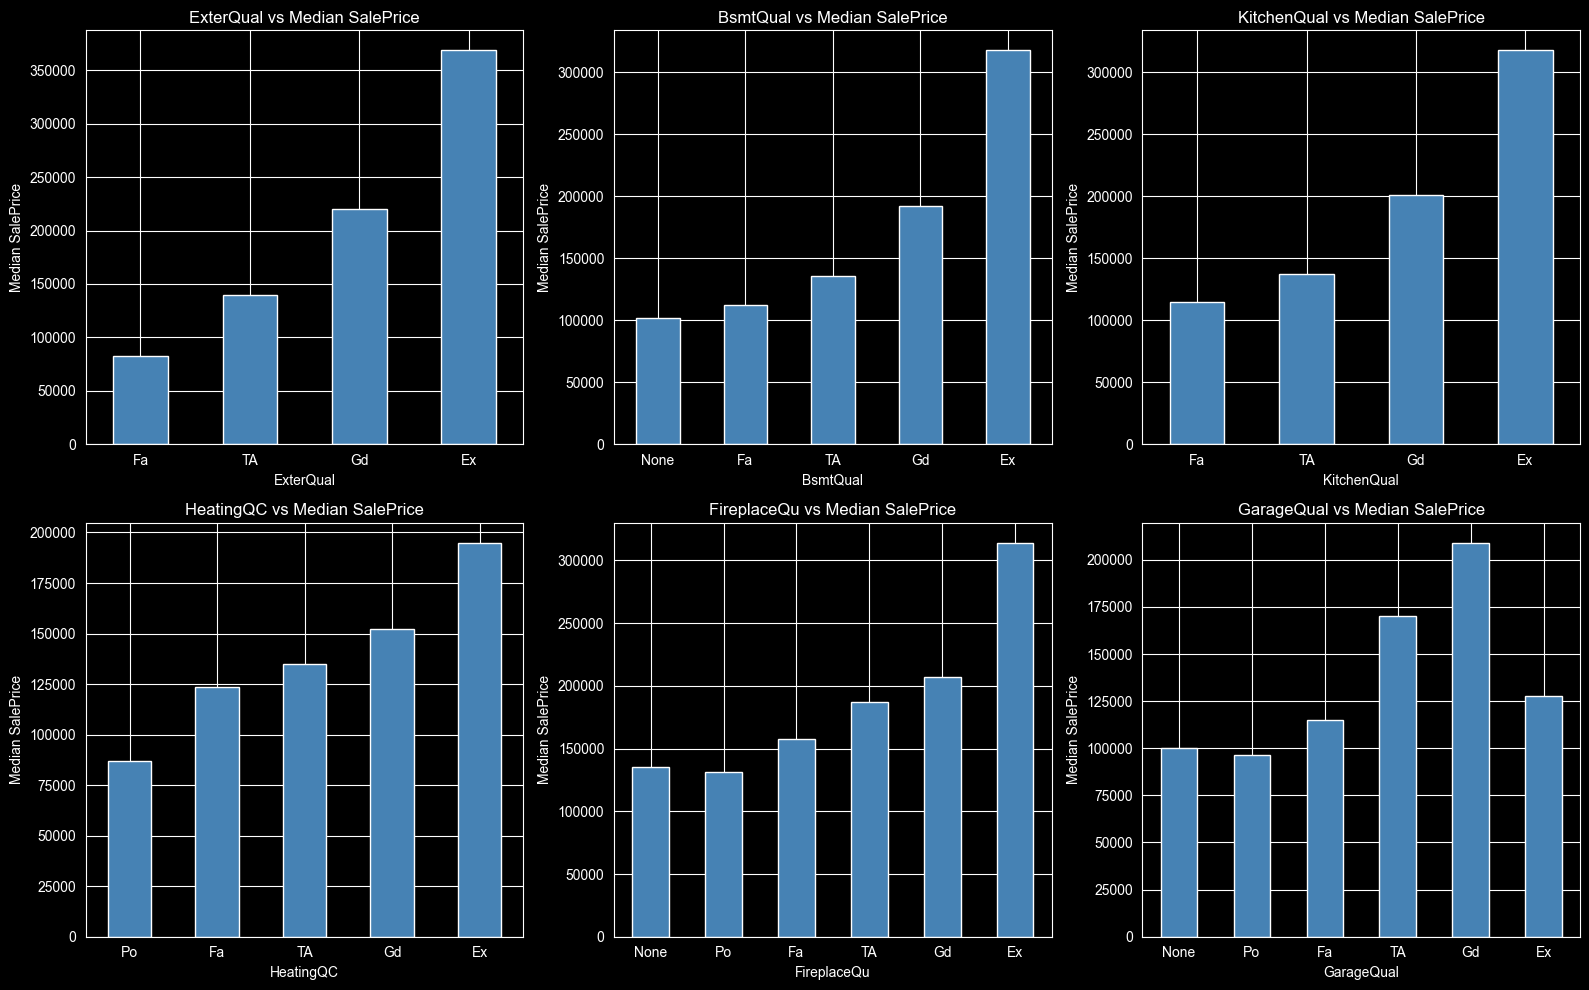

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
quality_cols = ['ExterQual', 'BsmtQual', 'KitchenQual', 'HeatingQC', 'FireplaceQu', 'GarageQual']
quality_order = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']

for ax, col in zip(axes.flat, quality_cols):
    data = train_df.copy()
    data[col] = data[col].fillna('None')
    order = [v for v in quality_order if v in data[col].unique()]
    medians = data.groupby(col)['SalePrice'].median().reindex(order)
    medians.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'{col} vs Median SalePrice')
    ax.set_ylabel('Median SalePrice')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 3.3 Create New Features

In [62]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Creates new derived features from existing columns."""

    ORDINAL_MAP = {
        'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5
    }
    BSMT_EXPOSURE_MAP = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
    BSMT_FIN_MAP = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
    FUNCTIONAL_MAP = {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8}
    GARAGE_FINISH_MAP = {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
    FENCE_MAP = {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}

    ORDINAL_COLS = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                    'HeatingQC', 'KitchenQual', 'FireplaceQu',
                    'GarageQual', 'GarageCond', 'PoolQC']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X['TotalSF'] = X['TotalBsmtSF'] + X['1stFlrSF'] + X['2ndFlrSF']
        X['TotalBath'] = X['FullBath'] + 0.5 * X['HalfBath'] + X['BsmtFullBath'] + 0.5 * X['BsmtHalfBath']
        X['TotalPorchSF'] = X['OpenPorchSF'] + X['EnclosedPorch'] + X['3SsnPorch'] + X['ScreenPorch']
        X['HouseAge'] = X['YrSold'] - X['YearBuilt']
        X['RemodAge'] = X['YrSold'] - X['YearRemodAdd']
        X['IsRemodeled'] = (X['YearBuilt'] != X['YearRemodAdd']).astype(int)
        X['HasGarage'] = (X['GarageArea'] > 0).astype(int)
        X['HasBsmt'] = (X['TotalBsmtSF'] > 0).astype(int)
        X['HasPool'] = (X['PoolArea'] > 0).astype(int)
        X['HasFireplace'] = (X['Fireplaces'] > 0).astype(int)
        X['Has2ndFloor'] = (X['2ndFlrSF'] > 0).astype(int)

        for col in self.ORDINAL_COLS:
            if col in X.columns:
                X[col] = X[col].map(self.ORDINAL_MAP).fillna(0).astype(int)

        if 'BsmtExposure' in X.columns:
            X['BsmtExposure'] = X['BsmtExposure'].map(self.BSMT_EXPOSURE_MAP).fillna(0).astype(int)
        if 'BsmtFinType1' in X.columns:
            X['BsmtFinType1'] = X['BsmtFinType1'].map(self.BSMT_FIN_MAP).fillna(0).astype(int)
        if 'BsmtFinType2' in X.columns:
            X['BsmtFinType2'] = X['BsmtFinType2'].map(self.BSMT_FIN_MAP).fillna(0).astype(int)
        if 'Functional' in X.columns:
            X['Functional'] = X['Functional'].map(self.FUNCTIONAL_MAP).fillna(0).astype(int)
        if 'GarageFinish' in X.columns:
            X['GarageFinish'] = X['GarageFinish'].map(self.GARAGE_FINISH_MAP).fillna(0).astype(int)
        if 'Fence' in X.columns:
            X['Fence'] = X['Fence'].map(self.FENCE_MAP).fillna(0).astype(int)

        if 'CentralAir' in X.columns:
            X['CentralAir'] = (X['CentralAir'] == 'Y').astype(int)
        if 'PavedDrive' in X.columns:
            X['PavedDrive'] = X['PavedDrive'].map({'N': 0, 'P': 1, 'Y': 2}).fillna(0).astype(int)
        if 'Street' in X.columns:
            X['Street'] = (X['Street'] == 'Pave').astype(int)

        return X


feat_eng = FeatureEngineer()
X_train_feat = feat_eng.transform(X_train_clean)
X_test_feat = feat_eng.transform(X_test_clean)

print(f"Shape after feature engineering: {X_train_feat.shape}")

Shape after feature engineering: (1458, 90)


## 3.4 Evaluate New Features

In [200]:
new_features = ['TotalSF', 'TotalBath', 'TotalPorchSF', 'HouseAge', 'RemodAge',
                'IsRemodeled', 'HasGarage', 'HasBsmt', 'HasPool', 'HasFireplace', 'Has2ndFloor']

new_corr = X_train_feat[new_features].corrwith(y_log).abs().sort_values(ascending=False)

original_features = ['GrLivArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
                     'FullBath', 'YearBuilt', 'YearRemodAdd']
orig_corr = X_train_feat[original_features].corrwith(y_log).abs().sort_values(ascending=False)


print("\nNEW features:")
for feat, corr in new_corr.items():
    print(f"  {feat:20s} -> |correlation| = {corr:.4f}")

print("\nORIGINAL features:")
for feat, corr in orig_corr.items():
    print(f"  {feat:20s} -> |correlation| = {corr:.4f}")



NEW features:
  TotalSF              -> |correlation| = 0.8253
  TotalBath            -> |correlation| = 0.6767
  HouseAge             -> |correlation| = 0.5878
  RemodAge             -> |correlation| = 0.5685
  HasFireplace         -> |correlation| = 0.5103
  HasGarage            -> |correlation| = 0.3230
  HasBsmt              -> |correlation| = 0.1996
  TotalPorchSF         -> |correlation| = 0.1956
  Has2ndFloor          -> |correlation| = 0.1506
  HasPool              -> |correlation| = 0.0765
  IsRemodeled          -> |correlation| = 0.0741

ORIGINAL features:
  GrLivArea            -> |correlation| = 0.7252
  TotalBsmtSF          -> |correlation| = 0.6476
  1stFlrSF             -> |correlation| = 0.6205
  FullBath             -> |correlation| = 0.5959
  YearBuilt            -> |correlation| = 0.5870
  YearRemodAdd         -> |correlation| = 0.5660
  2ndFlrSF             -> |correlation| = 0.3200


## 3.5 One-Hot Encoding

In [64]:
NOMINAL_COLS = [
    'MSZoning', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
    'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
    'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
    'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType',
    'MiscFeature', 'SaleType', 'SaleCondition'
]

NOMINAL_COLS = [c for c in NOMINAL_COLS if c in X_train_feat.columns]


class NominalEncoder(BaseEstimator, TransformerMixin):
    """One-hot encodes nominal categorical columns."""

    def __init__(self, columns):
        self.columns = columns
        self.encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
        self.other_cols_ = []

    def fit(self, X, y=None):
        existing = [c for c in self.columns if c in X.columns]
        self.columns_ = existing
        self.other_cols_ = [c for c in X.columns if c not in existing]
        self.encoder.fit(X[existing])
        return self

    def transform(self, X):
        X = X.copy()
        encoded = self.encoder.transform(X[self.columns_])
        encoded_df = pd.DataFrame(
            encoded,
            columns=self.encoder.get_feature_names_out(self.columns_),
            index=X.index
        )
        result = pd.concat([X[self.other_cols_].reset_index(drop=True),
                            encoded_df.reset_index(drop=True)], axis=1)
        return result


nom_encoder = NominalEncoder(columns=NOMINAL_COLS)
nom_encoder.fit(X_train_feat)

X_train_encoded = nom_encoder.transform(X_train_feat)
X_test_encoded = nom_encoder.transform(X_test_feat)

print(f"Before OHE: {X_train_feat.shape[1]} columns")
print(f"After OHE:  {X_train_encoded.shape[1]} columns")

Before OHE: 90 columns
After OHE:  215 columns


## 3.6 Skewness Correction

In [201]:
num_cols = X_train_encoded.select_dtypes(include='number').columns
skewed = X_train_encoded[num_cols].apply(lambda x: x.skew()).sort_values(ascending=False)
skewed_features = skewed[skewed.abs() > 0.75].index.tolist()

print(f"Found {len(skewed_features)} features |skewness| > 0.75")
print(skewed.head(10))

for col in skewed_features:
    if (X_train_encoded[col] >= 0).all():
        X_train_encoded[col] = np.log1p(X_train_encoded[col])
        X_test_encoded[col] = np.log1p(X_test_encoded[col])


Found 167 features |skewness| > 0.75
Condition2_RRAn        38.183766
Exterior1st_CBlock     38.183766
RoofMatl_Membran       38.183766
Exterior2nd_CBlock     38.183766
Exterior1st_ImStucc    38.183766
MiscFeature_TenC       38.183766
Exterior1st_AsphShn    38.183766
Condition2_PosN        38.183766
RoofMatl_Roll          38.183766
RoofMatl_Metal         38.183766
dtype: float64


---
# 4. Feature Selection

## 4.1 Correlation Filter

In [66]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.85):
        self.threshold = threshold
        self.cols_to_drop_ = []

    def fit(self, X, y=None):
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.cols_to_drop_ = [col for col in upper.columns if any(upper[col] > self.threshold)]
        return self

    def transform(self, X):
        return X.drop(columns=self.cols_to_drop_, errors='ignore')


corr_filter = CorrelationFilter(threshold=0.85)
corr_filter.fit(X_train_encoded)

X_train_corr = corr_filter.transform(X_train_encoded)
X_test_corr = corr_filter.transform(X_test_encoded)

print(f"threshold=0.85")
print(f"  Before: {X_train_encoded.shape[1]}")
print(f"  After:  {X_train_corr.shape[1]}")
print(f"  Dropped {len(corr_filter.cols_to_drop_)} highly correlated features")
print(f"\nDropped columns: {corr_filter.cols_to_drop_}")

threshold=0.85
  Before: 215
  After:  186
  Dropped 29 highly correlated features

Dropped columns: ['BsmtFinSF1', 'BsmtFinSF2', 'FireplaceQu', 'GarageArea', 'GarageQual', 'GarageCond', 'PoolQC', 'TotalSF', 'HouseAge', 'RemodAge', 'HasGarage', 'HasBsmt', 'HasPool', 'HasFireplace', 'Has2ndFloor', 'Neighborhood_Somerst', 'HouseStyle_1Story', 'RoofStyle_Hip', 'Exterior2nd_CBlock', 'Exterior2nd_CmentBd', 'Exterior2nd_HdBoard', 'Exterior2nd_MetalSd', 'Exterior2nd_VinylSd', 'Exterior2nd_Wd Sdng', 'MasVnrType_None', 'GarageType_None', 'MiscFeature_None', 'MiscFeature_Shed', 'SaleCondition_Partial']


## 4.2 Feature Importance (Random Forest)

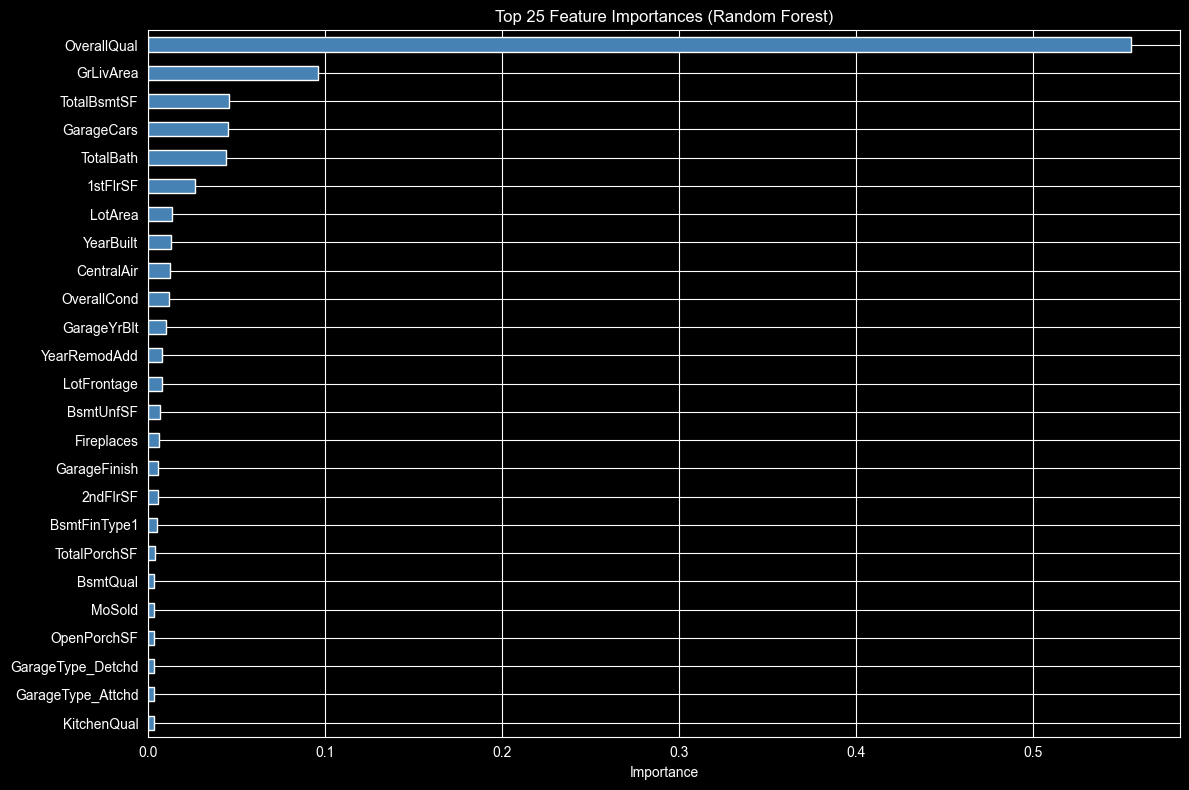


important > 0.001: 44
noise: 142


In [69]:
rf_importance = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_importance.fit(X_train_corr, y_log)

importances = pd.Series(rf_importance.feature_importances_, index=X_train_corr.columns)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
importances.head(25).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 25 Feature Importances (Random Forest)')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

importance_threshold = 0.001
important_features = importances[importances > importance_threshold].index.tolist()
unimportant = importances[importances <= importance_threshold]

print(f"\nimportant > {importance_threshold}: {len(important_features)}")
print(f"noise: {len(unimportant)}")

X_train_imp = X_train_corr[important_features]
X_test_imp = X_test_corr[important_features]

## 4.3 RFE

In [67]:
rfe_estimator = Ridge(alpha=1.0)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=50, step=10)
rfe.fit(X_train_corr, y_log)

rfe_features = X_train_corr.columns[rfe.support_].tolist()
print(f" {len(rfe_features)} features")
print(f"\nSelected features: {rfe_features}")

X_train_rfe = X_train_corr[rfe_features]
X_test_rfe = X_test_corr[rfe_features]

 50 features

Selected features: ['LotArea', 'Street', 'OverallQual', 'ExterQual', 'BsmtQual', 'BsmtExposure', 'CentralAir', '1stFlrSF', 'GrLivArea', 'KitchenAbvGr', 'Functional', 'TotalBath', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Utilities_NoSeWa', 'LotConfig_CulDSac', 'LotConfig_FR3', 'LandSlope_Sev', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_StoneBr', 'Condition1_Feedr', 'Condition1_Norm', 'Condition1_PosN', 'Condition1_RRAn', 'Condition1_RRNn', 'RoofStyle_Shed', 'RoofMatl_Membran', 'RoofMatl_Metal', 'RoofMatl_WdShngl', 'Exterior1st_BrkComm', 'Exterior1st_BrkFace', 'Exterior2nd_BrkFace', 'Foundation_Slab', 'Foundation_Stone', 'Heating_Grav', 'Heating_OthW', 'GarageType_CarPort', 'SaleType_Con', 'SaleType_ConLD', 'SaleType_New', 'SaleCondition_Normal']


## 4.4 Mutual Information


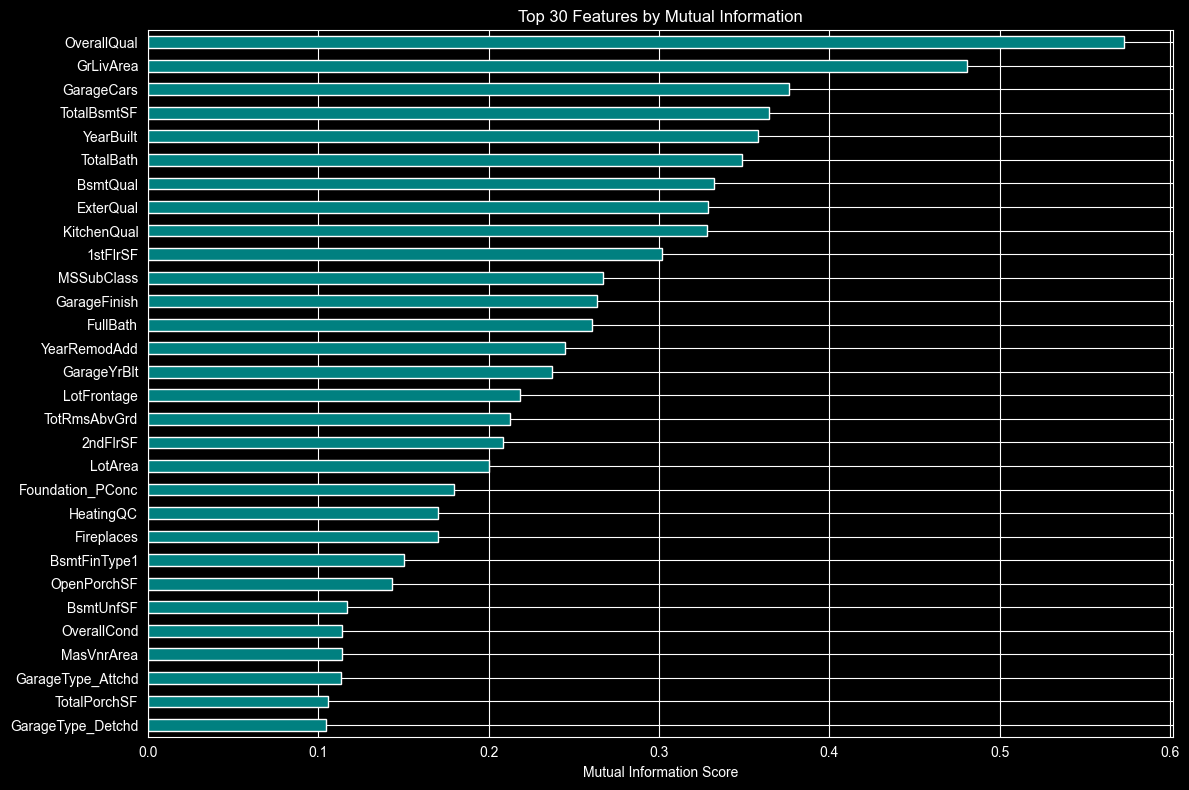


MI > 0.05: 45
below threshold: 141

Top 10 by MI:
  OverallQual                    -> MI = 0.5729
  GrLivArea                      -> MI = 0.4805
  GarageCars                     -> MI = 0.3761
  TotalBsmtSF                    -> MI = 0.3646
  YearBuilt                      -> MI = 0.3582
  TotalBath                      -> MI = 0.3485
  BsmtQual                       -> MI = 0.3323
  ExterQual                      -> MI = 0.3287
  KitchenQual                    -> MI = 0.3282
  1stFlrSF                       -> MI = 0.3016


In [71]:

mi_scores = mutual_info_regression(X_train_corr, y_log, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train_corr.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
mi_series.head(30).plot(kind='barh', ax=ax, color='teal')
ax.set_title('Top 30 Features by Mutual Information')
ax.set_xlabel('Mutual Information Score')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

mi_threshold = 0.05
mi_features = mi_series[mi_series > mi_threshold].index.tolist()
print(f"\nMI > {mi_threshold}: {len(mi_features)}")
print(f"below threshold: {len(mi_series) - len(mi_features)}")

print(f"\nTop 10 by MI:")
for feat, score in mi_series.head(10).items():
    print(f"  {feat:30s} -> MI = {score:.4f}")


X_train_mi = X_train_corr[mi_features]
X_test_mi = X_test_corr[mi_features]

## 4.5 Permutation Importance

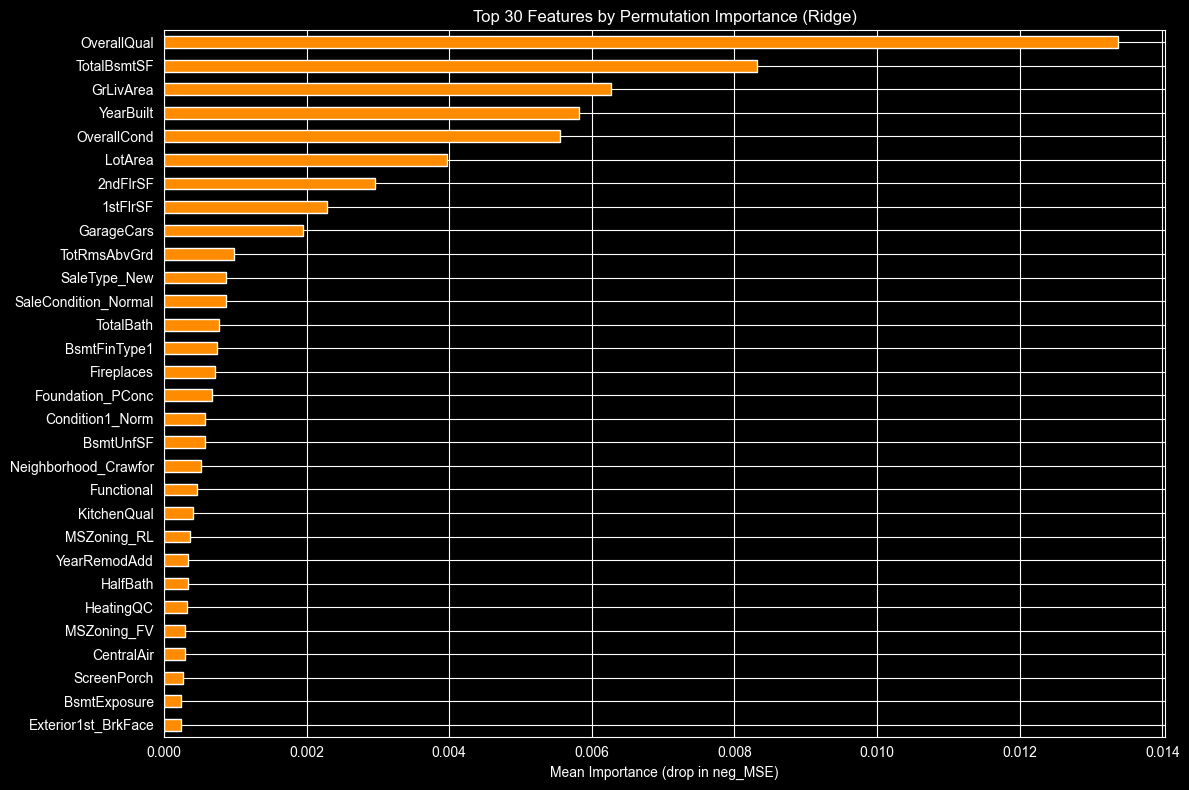


permutation importance > 0.0001: 45

ტop 10
  OverallQual                    -> importance = 0.013372
  TotalBsmtSF                    -> importance = 0.008310
  GrLivArea                      -> importance = 0.006268
  YearBuilt                      -> importance = 0.005824
  OverallCond                    -> importance = 0.005559
  LotArea                        -> importance = 0.003972
  2ndFlrSF                       -> importance = 0.002965
  1stFlrSF                       -> importance = 0.002292
  GarageCars                     -> importance = 0.001951
  TotRmsAbvGrd                   -> importance = 0.000983


In [75]:

perm_model = Ridge(alpha=10)
perm_model.fit(X_train_corr, y_log)
perm_result = permutation_importance(perm_model, X_train_corr, y_log,
                                      n_repeats=10, random_state=42,
                                      scoring='neg_mean_squared_error')

perm_series = pd.Series(perm_result.importances_mean, index=X_train_corr.columns)
perm_series = perm_series.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
perm_series.head(30).plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Top 30 Features by Permutation Importance (Ridge)')
ax.set_xlabel('Mean Importance (drop in neg_MSE)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

perm_threshold = 0.0001
perm_features = perm_series[perm_series > perm_threshold].index.tolist()
print(f"\npermutation importance > {perm_threshold}: {len(perm_features)}")
print(f"\nტop 10")
for feat, score in perm_series.head(10).items():
    print(f"  {feat:30s} -> importance = {score:.6f}")

X_train_perm = X_train_corr[perm_features]
X_test_perm = X_test_corr[perm_features]

## 4.6 Feature Selection Comparison

  All (post-corr-filter)    |  186 features | CV RMSE: 0.11515 (+/- 0.00790)
  RF Importance Filter      |   44 features | CV RMSE: 0.12431 (+/- 0.00672)
  RFE (50 features)         |   50 features | CV RMSE: 0.13209 (+/- 0.00768)
  Mutual Information        |   45 features | CV RMSE: 0.12305 (+/- 0.00950)
  Permutation Importance    |   45 features | CV RMSE: 0.11462 (+/- 0.00740)

  Permutation Importance CV RMSE = 0.11462


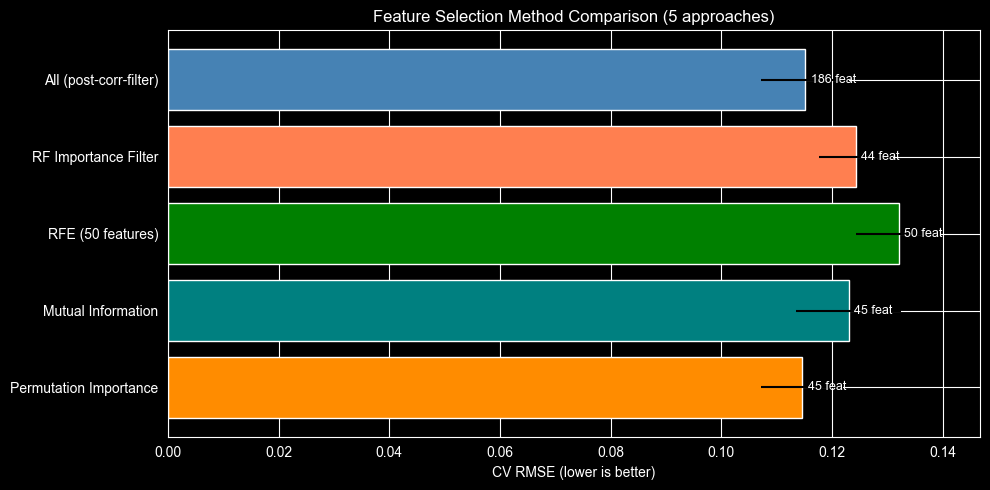

In [80]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
feature_sets = {
    'All (post-corr-filter)': (X_train_corr, X_test_corr),
    'RF Importance Filter': (X_train_imp, X_test_imp),
    'RFE (50 features)': (X_train_rfe, X_test_rfe),
    'Mutual Information': (X_train_mi, X_test_mi),
    'Permutation Importance': (X_train_perm, X_test_perm),
}

fs_results = []
best_score = float('inf')
best_fs_name = None

for name, (X_fs, _) in feature_sets.items():
    scores = cross_val_score(Ridge(alpha=10), X_fs, y_log,
                             cv=kfold, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)
    mean_rmse = rmse_scores.mean()
    std_rmse = rmse_scores.std()
    fs_results.append({'method': name, 'n_features': X_fs.shape[1],
                       'cv_rmse': mean_rmse, 'std': std_rmse})
    print(f"  {name:25s} | {X_fs.shape[1]:4d} features | CV RMSE: {mean_rmse:.5f} (+/- {std_rmse:.5f})")

    if mean_rmse < best_score:
        best_score = mean_rmse
        best_fs_name = name

print(f"\n  {best_fs_name} CV RMSE = {best_score:.5f}")
fs_df = pd.DataFrame(fs_results)
colors = ['steelblue', 'coral', 'green', 'teal', 'darkorange']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(fs_df['method'], fs_df['cv_rmse'], xerr=fs_df['std'], color=colors)
ax.set_xlabel('CV RMSE (lower is better)')
ax.set_title('Feature Selection Method Comparison (5 approaches)')
ax.invert_yaxis()
for bar, n in zip(bars, fs_df['n_features']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{n} feat', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [82]:
X_train_final, X_test_final = feature_sets[best_fs_name]
print(f"'{best_fs_name}' with {X_train_final.shape[1]} features")

'Permutation Importance' with 45 features


---
# 5. Training

In [83]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final, y_log, test_size=0.2, random_state=42
)
print(f"Train: {X_tr.shape}, Validation: {X_val.shape}")

scaler = StandardScaler()
X_tr_scaled = pd.DataFrame(scaler.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)

all_results = []

Train: (1166, 45), Validation: (292, 45)


In [168]:
def train_evaluate(model, X_train, y_train, X_val, y_val):
    """Train and return metrics dict without logging to MLflow."""
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    train_r2 = r2_score(y_train, train_preds)
    val_r2 = r2_score(y_val, val_preds)
    train_mae = mean_absolute_error(y_train, train_preds)
    val_mae = mean_absolute_error(y_val, val_preds)

    cv_scores = cross_val_score(model, X_train, y_train, cv=kfold,
                                scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores).mean()

    overfit_ratio = val_rmse / train_rmse if train_rmse > 0 else float('inf')

    return {
        'train_rmse': train_rmse, 'val_rmse': val_rmse,
        'train_r2': train_r2, 'val_r2': val_r2,
        'train_mae': train_mae, 'val_mae': val_mae,
        'cv_rmse': cv_rmse, 'overfit_ratio': overfit_ratio
    }


def log_to_mlflow(run_name, model, metrics, params, experiment_name, register=False):
    """Log a single run to a specific MLflow experiment."""
    mlflow.set_experiment(experiment_name)
    with mlflow.start_run(run_name=run_name):
        for k, v in params.items():
            mlflow.log_param(k, v)
        mlflow.log_param("feature_selection", best_fs_name)
        mlflow.log_param("n_features", X_tr.shape[1])

        for k, v in metrics.items():
            mlflow.log_metric(k, v)

        if register:
            mlflow.sklearn.log_model(
                model, "model",
                registered_model_name="HousePrices_BestModel"
            )
        else:
            mlflow.sklearn.log_model(model, "model")

    print(f"  >> Logged to MLflow experiment '{experiment_name}': {run_name}")


def print_metrics(name, m):
    """Print standard metrics with explanations."""
    print(f"  Train RMSE: {m['train_rmse']:.5f}  ")
    print(f"  Val RMSE:   {m['val_rmse']:.5f} ")
    print(f"  CV RMSE:    {m['cv_rmse']:.5f}")
    print(f"  Val R\u00b2:     {m['val_r2']:.4f}")
    print(f"  Overfit:    {m['overfit_ratio']:.3f}")

## 5.1 Linear Regression

In [86]:
lr_model = LinearRegression()
lr_metrics = train_evaluate(lr_model, X_tr_scaled, y_tr, X_val_scaled, y_val)

print(f"  train RMSE: {lr_metrics['train_rmse']:.5f}")
print(f"  val RMSE:   {lr_metrics['val_rmse']:.5f}")
print(f"  CV RMSE:    {lr_metrics['cv_rmse']:.5f}")
print(f"  Val R²:     {lr_metrics['val_r2']:.4f}")
print(f"  Overfit:    {lr_metrics['overfit_ratio']:.3f}")
all_results.append({'name': 'LinearRegression', 'model': lr_model, **lr_metrics})
# LOG TO MLFLOW (run this cell separately for distinct timestamp)
log_to_mlflow("LinearRegression_Baseline", lr_model, lr_metrics,
              {'model_type': 'LinearRegression'},
              experiment_name="LinearRegression_Baseline")

  train RMSE: 0.10653
  val RMSE:   0.11425
  CV RMSE:    0.11300
  Val R²:     0.9226
  Overfit:    1.072


## 5.2 Ridge Regression (L2 Regularization)

L2 penalty shrinks coefficients toward zero, reducing overfitting.
We test multiple alpha values — each in its own cell for independent analysis.

In [87]:
ridge_all = []

In [169]:
ridge_a01_model = Ridge(alpha=0.1)
ridge_a01_m = train_evaluate(ridge_a01_model, X_tr_scaled, y_tr, X_val_scaled, y_val)
print_metrics("Ridge alpha=0.1", ridge_a01_m)
ridge_all.append({'alpha': 0.1, 'model': ridge_a01_model, **ridge_a01_m})
log_to_mlflow("Ridge_alpha=0.1", ridge_a01_model, ridge_a01_m,
             {'model_type': 'Ridge', 'alpha': 0.1},
           experiment_name="Ridge_alpha=0.1")

  Train RMSE: 0.10653  
  Val RMSE:   0.11425 
  CV RMSE:    0.11300
  Val R²:     0.9226
  Overfit:    1.072


In [170]:

ridge_a1_model = Ridge(alpha=1.0)
ridge_a1_m = train_evaluate(ridge_a1_model, X_tr_scaled, y_tr, X_val_scaled, y_val)
print_metrics("Ridge alpha=1.0", ridge_a1_m)
ridge_all.append({'alpha': 1.0, 'model': ridge_a1_model, **ridge_a1_m})
log_to_mlflow("Ridge_alpha=1.0", ridge_a1_model, ridge_a1_m,
             {'model_type': 'Ridge', 'alpha': 1.0},
             experiment_name="Ridge_alpha=1.0")

  Train RMSE: 0.10653  
  Val RMSE:   0.11424 
  CV RMSE:    0.11297
  Val R²:     0.9226
  Overfit:    1.072


In [171]:

ridge_a10_model = Ridge(alpha=10.0)
ridge_a10_m = train_evaluate(ridge_a10_model, X_tr_scaled, y_tr, X_val_scaled, y_val)
print_metrics("Ridge alpha=10.0", ridge_a10_m)
ridge_all.append({'alpha': 10.0, 'model': ridge_a10_model, **ridge_a10_m})
log_to_mlflow("Ridge_alpha=10.0", ridge_a10_model, ridge_a10_m,
              {'model_type': 'Ridge', 'alpha': 10.0},
              experiment_name="Ridge_alpha=10.0")

  Train RMSE: 0.10658  
  Val RMSE:   0.11427 
  CV RMSE:    0.11281
  Val R²:     0.9225
  Overfit:    1.072


In [172]:

ridge_a50_model = Ridge(alpha=50.0)
ridge_a50_m = train_evaluate(ridge_a50_model, X_tr_scaled, y_tr, X_val_scaled, y_val)
print_metrics("Ridge alpha=50.0", ridge_a50_m)
ridge_all.append({'alpha': 50.0, 'model': ridge_a50_model, **ridge_a50_m})
log_to_mlflow("Ridge_alpha=50.0", ridge_a50_model, ridge_a50_m,
            {'model_type': 'Ridge', 'alpha': 50.0},
            experiment_name="Ridge_alpha=50.0")

  Train RMSE: 0.10706  
  Val RMSE:   0.11498 
  CV RMSE:    0.11286
  Val R²:     0.9216
  Overfit:    1.074


In [173]:

ridge_a100_model = Ridge(alpha=100.0)
ridge_a100_m = train_evaluate(ridge_a100_model, X_tr_scaled, y_tr, X_val_scaled, y_val)
print_metrics("Ridge alpha=100.0", ridge_a100_m)
ridge_all.append({'alpha': 100.0, 'model': ridge_a100_model, **ridge_a100_m})
log_to_mlflow("Ridge_alpha=100.0", ridge_a100_model, ridge_a100_m,
            {'model_type': 'Ridge', 'alpha': 100.0},
             experiment_name="Ridge_alpha=100.0")

  Train RMSE: 0.10783  
  Val RMSE:   0.11611 
  CV RMSE:    0.11342
  Val R²:     0.9200
  Overfit:    1.077


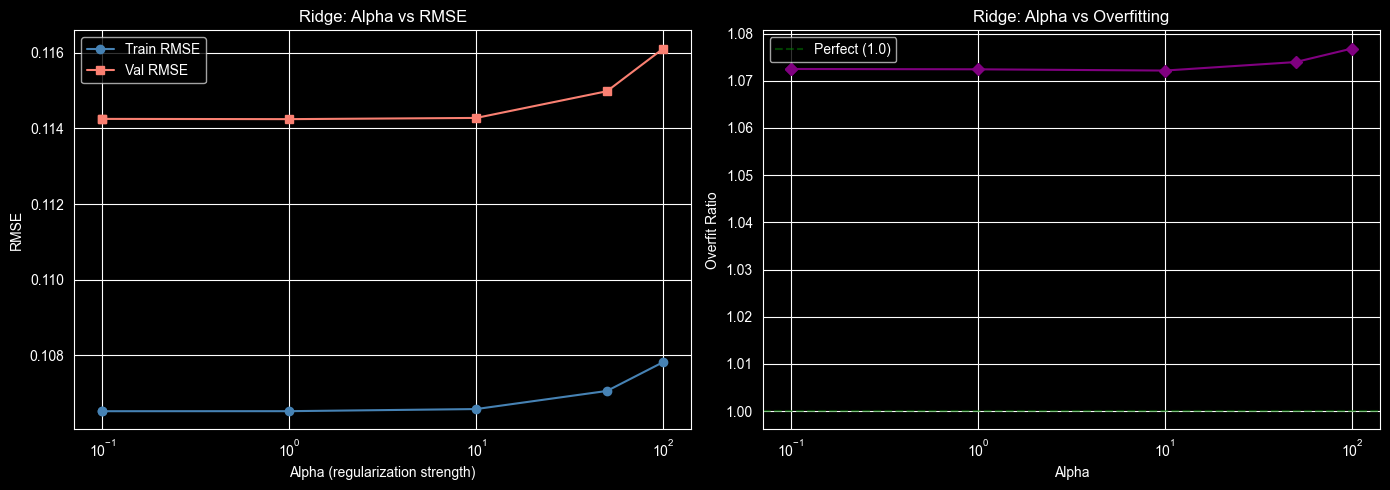


 alpha = 1.0 val RMSE = 0.11424


In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
alphas = [r['alpha'] for r in ridge_all]
axes[0].plot(alphas, [r['train_rmse'] for r in ridge_all], 'o-', label='Train RMSE', color='steelblue')
axes[0].plot(alphas, [r['val_rmse'] for r in ridge_all], 's-', label='Val RMSE', color='salmon')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (regularization strength)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Ridge: Alpha vs RMSE')
axes[0].legend()

axes[1].plot(alphas, [r['overfit_ratio'] for r in ridge_all], 'D-', color='purple')
axes[1].axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Perfect (1.0)')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Overfit Ratio')
axes[1].set_title('Ridge: Alpha vs Overfitting')
axes[1].legend()
plt.tight_layout()
plt.show()

best_ridge = min(ridge_all, key=lambda x: x['val_rmse'])
print(f"\n alpha = {best_ridge['alpha']} val RMSE = {best_ridge['val_rmse']:.5f}")
all_results.append({'name': f'Ridge_alpha={best_ridge["alpha"]}', 'model': best_ridge['model'],
                    **{k: v for k, v in best_ridge.items() if k not in ['alpha', 'model']}})

## 5.3 Lasso Regression

In [98]:
lasso_all = []

In [174]:

lasso_a0001_model = Lasso(alpha=0.0001, max_iter=10000)
lasso_a0001_m = train_evaluate(lasso_a0001_model, X_tr_scaled, y_tr, X_val_scaled, y_val)
print_metrics("Lasso alpha=0.0001", lasso_a0001_m)
lasso_all.append({'alpha': 0.0001, 'n_nonzero': np.sum(np.abs(lasso_a0001_model.coef_) > 1e-10), 'model': lasso_a0001_model, **lasso_a0001_m})
log_to_mlflow("Lasso_alpha=0.0001", lasso_a0001_model, lasso_a0001_m,
              {'model_type': 'Lasso', 'alpha': 0.0001, 'n_nonzero': np.sum(np.abs(lasso_a0001_model.coef_) > 1e-10)},
              experiment_name="Lasso_alpha=0.0001")

  Train RMSE: 0.10653  
  Val RMSE:   0.11426 
  CV RMSE:    0.11289
  Val R²:     0.9225
  Overfit:    1.073


In [175]:

lasso_a001_model = Lasso(alpha=0.001, max_iter=10000)
lasso_a001_m = train_evaluate(lasso_a001_model, X_tr_scaled, y_tr, X_val_scaled, y_val)
print_metrics("Lasso alpha=0.001", lasso_a001_m)
lasso_all.append({'alpha': 0.001, 'n_nonzero': np.sum(np.abs(lasso_a001_model.coef_) > 1e-10), 'model': lasso_a001_model, **lasso_a001_m})
log_to_mlflow("Lasso_alpha=0.001", lasso_a001_model, lasso_a001_m,
              {'model_type': 'Lasso', 'alpha': 0.001, 'n_nonzero': np.sum(np.abs(lasso_a001_model.coef_) > 1e-10)},
              experiment_name="Lasso_alpha=0.001")

  Train RMSE: 0.10672  
  Val RMSE:   0.11438 
  CV RMSE:    0.11263
  Val R²:     0.9224
  Overfit:    1.072


In [176]:

lasso_a01_model = Lasso(alpha=0.01, max_iter=10000)
lasso_a01_m = train_evaluate(lasso_a01_model, X_tr_scaled, y_tr, X_val_scaled, y_val)
print_metrics("Lasso alpha=0.01", lasso_a01_m)
lasso_all.append({'alpha': 0.01, 'n_nonzero': np.sum(np.abs(lasso_a01_model.coef_) > 1e-10), 'model': lasso_a01_model, **lasso_a01_m})
log_to_mlflow("Lasso_alpha=0.01", lasso_a01_model, lasso_a01_m,
              {'model_type': 'Lasso', 'alpha': 0.01, 'n_nonzero': np.sum(np.abs(lasso_a01_model.coef_) > 1e-10)},
              experiment_name="Lasso_alpha=0.01")

  Train RMSE: 0.11767  
  Val RMSE:   0.12737 
  CV RMSE:    0.12110
  Val R²:     0.9038
  Overfit:    1.082


In [177]:


lasso_a1_model = Lasso(alpha=0.1, max_iter=10000)
lasso_a1_m = train_evaluate(lasso_a1_model, X_tr_scaled, y_tr, X_val_scaled, y_val)
print_metrics("Lasso alpha=0.1", lasso_a1_m)
lasso_all.append({'alpha': 0.1, 'n_nonzero': np.sum(np.abs(lasso_a1_model.coef_) > 1e-10), 'model': lasso_a1_model, **lasso_a1_m})
log_to_mlflow("Lasso_alpha=0.1", lasso_a1_model, lasso_a1_m,
             {'model_type': 'Lasso', 'alpha': 0.1, 'n_nonzero': np.sum(np.abs(lasso_a1_model.coef_) > 1e-10)},
              experiment_name="Lasso_alpha=0.1")

  Train RMSE: 0.20061  
  Val RMSE:   0.20736 
  CV RMSE:    0.20192
  Val R²:     0.7449
  Overfit:    1.034


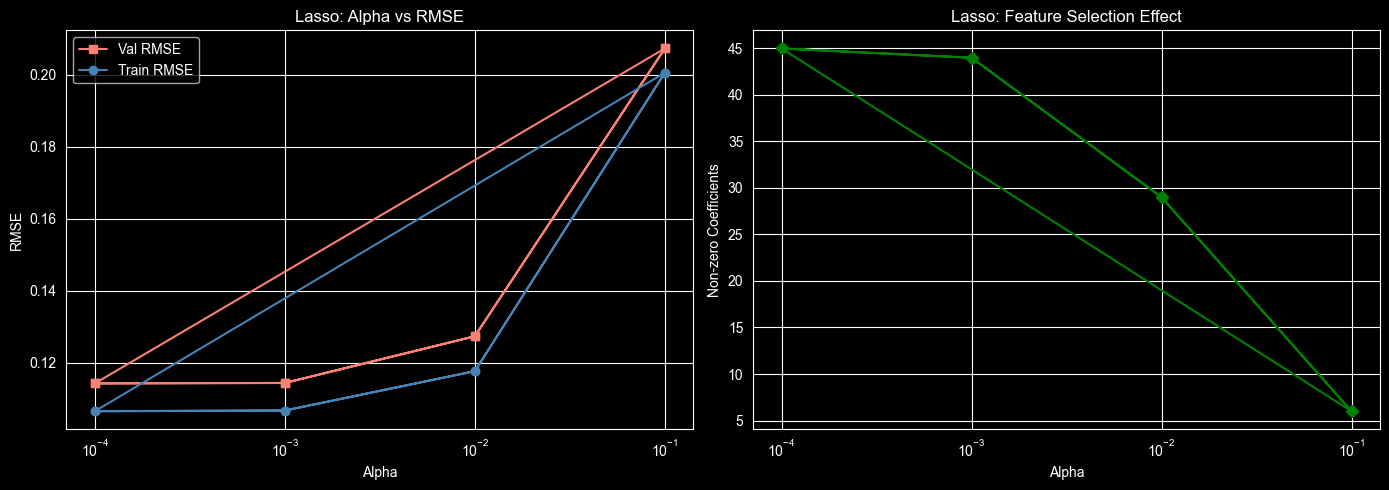


alpha = 0.0001 (Val RMSE = 0.11426)
   non-zero coefficients: 45


In [158]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
alphas = [r['alpha'] for r in lasso_all]
axes[0].plot(alphas, [r['val_rmse'] for r in lasso_all], 's-', color='salmon', label='Val RMSE')
axes[0].plot(alphas, [r['train_rmse'] for r in lasso_all], 'o-', color='steelblue', label='Train RMSE')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Lasso: Alpha vs RMSE')
axes[0].legend()

axes[1].plot(alphas, [r['n_nonzero'] for r in lasso_all], 'D-', color='green')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Non-zero Coefficients')
axes[1].set_title('Lasso: Feature Selection Effect')
plt.tight_layout()
plt.show()

best_lasso = min(lasso_all, key=lambda x: x['val_rmse'])
print(f"\nalpha = {best_lasso['alpha']} (Val RMSE = {best_lasso['val_rmse']:.5f})")
print(f"   non-zero coefficients: {best_lasso['n_nonzero']}")

all_results.append({'name': f'Lasso_alpha={best_lasso["alpha"]}', 'model': best_lasso['model'],
                    **{k: v for k, v in best_lasso.items() if k not in ['alpha', 'model', 'n_nonzero']}})

## 5.4 ElasticNet

In [106]:
enet_results = []
enet_grid = [
    (0.0005, 0.2), (0.0005, 0.5), (0.0005, 0.8),
    (0.001, 0.2), (0.001, 0.5), (0.001, 0.8),
    (0.005, 0.2), (0.005, 0.5), (0.005, 0.8),
    (0.01, 0.3), (0.01, 0.7),
]

for alpha, l1 in enet_grid:
    model = ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000)
    m = train_evaluate(model, X_tr_scaled, y_tr, X_val_scaled, y_val)
    m['alpha'] = alpha
    m['l1_ratio'] = l1
    m['model'] = model
    enet_results.append(m)
    print(f"  alpha={alpha:.4f}, l1={l1:.1f} | val RMSE: {m['val_rmse']:.5f} | overfit: {m['overfit_ratio']:.3f}")

best_enet = min(enet_results, key=lambda x: x['val_rmse'])
print(f"\nalpha={best_enet['alpha']}, l1_ratio={best_enet['l1_ratio']}")
print(f"   Val RMSE = {best_enet['val_rmse']:.5f}")

all_results.append({'name': f'ElasticNet_a={best_enet["alpha"]}_l1={best_enet["l1_ratio"]}',
                    'model': best_enet['model'],
                    **{k: v for k, v in best_enet.items() if k not in ['alpha', 'l1_ratio', 'model']}})
for r in enet_results:
    exp_name = f"ElasticNet_a={r['alpha']}_l1={r['l1_ratio']}"
    log_to_mlflow(exp_name, r['model'],
                  {k: v for k, v in r.items() if k not in ['alpha', 'l1_ratio', 'model']},
                  {'model_type': 'ElasticNet', 'alpha': r['alpha'], 'l1_ratio': r['l1_ratio']},
                  experiment_name=exp_name)

  alpha=0.0005, l1=0.2 | val RMSE: 0.11426 | overfit: 1.073
  alpha=0.0005, l1=0.5 | val RMSE: 0.11428 | overfit: 1.073
  alpha=0.0005, l1=0.8 | val RMSE: 0.11428 | overfit: 1.072
  alpha=0.0010, l1=0.2 | val RMSE: 0.11427 | overfit: 1.073
  alpha=0.0010, l1=0.5 | val RMSE: 0.11429 | overfit: 1.072
  alpha=0.0010, l1=0.8 | val RMSE: 0.11433 | overfit: 1.072
  alpha=0.0050, l1=0.2 | val RMSE: 0.11449 | overfit: 1.072
  alpha=0.0050, l1=0.5 | val RMSE: 0.11515 | overfit: 1.070
  alpha=0.0050, l1=0.8 | val RMSE: 0.11644 | overfit: 1.067
  alpha=0.0100, l1=0.3 | val RMSE: 0.11570 | overfit: 1.070
  alpha=0.0100, l1=0.7 | val RMSE: 0.12165 | overfit: 1.074

alpha=0.0005, l1_ratio=0.2
   Val RMSE = 0.11426


## 5.5 Decision Tree

In [107]:
dt_all = []

In [178]:


dt_d3_model = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_d3_m = train_evaluate(dt_d3_model, X_tr, y_tr, X_val, y_val)
print_metrics("Decision Tree depth=3", dt_d3_m)
dt_all.append({'config': 'depth=3', 'model': dt_d3_model, **dt_d3_m})
log_to_mlflow("DT_depth3", dt_d3_model, dt_d3_m,
             {'model_type': 'DecisionTree', 'max_depth': 3},
              experiment_name="DT_depth3")

  Train RMSE: 0.21122  
  Val RMSE:   0.22934 
  CV RMSE:    0.22565
  Val R²:     0.6880
  Overfit:    1.086


In [179]:

dt_d5_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_d5_m = train_evaluate(dt_d5_model, X_tr, y_tr, X_val, y_val)
print_metrics("Decision Tree depth=5", dt_d5_m)
dt_all.append({'config': 'depth=5', 'model': dt_d5_model, **dt_d5_m})
log_to_mlflow("DT_depth5", dt_d5_model, dt_d5_m,
              {'model_type': 'DecisionTree', 'max_depth': 5},
              experiment_name="DT_depth5")

  Train RMSE: 0.15752  
  Val RMSE:   0.21713 
  CV RMSE:    0.19653
  Val R²:     0.7203
  Overfit:    1.378


In [180]:


dt_d10_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_d10_m = train_evaluate(dt_d10_model, X_tr, y_tr, X_val, y_val)
print_metrics("Decision Tree depth=10", dt_d10_m)
dt_all.append({'config': 'depth=10', 'model': dt_d10_model, **dt_d10_m})
log_to_mlflow("DT_depth10", dt_d10_model, dt_d10_m,
              {'model_type': 'DecisionTree', 'max_depth': 10},
              experiment_name="DT_depth10")

  Train RMSE: 0.05869  
  Val RMSE:   0.20679 
  CV RMSE:    0.19535
  Val R²:     0.7463
  Overfit:    3.523


In [181]:

dt_d15_model = DecisionTreeRegressor(max_depth=15, random_state=42)
dt_d15_m = train_evaluate(dt_d15_model, X_tr, y_tr, X_val, y_val)
print_metrics("Decision Tree depth=15", dt_d15_m)
dt_all.append({'config': 'depth=15', 'model': dt_d15_model, **dt_d15_m})
log_to_mlflow("DT_depth15", dt_d15_model, dt_d15_m,
              {'model_type': 'DecisionTree', 'max_depth': 15},
              experiment_name="DT_depth15")

  Train RMSE: 0.01637  
  Val RMSE:   0.20756 
  CV RMSE:    0.20339
  Val R²:     0.7444
  Overfit:    12.677


In [182]:


dt_dNone_model = DecisionTreeRegressor(max_depth=None, random_state=42)
dt_dNone_m = train_evaluate(dt_dNone_model, X_tr, y_tr, X_val, y_val)
print_metrics("Decision Tree depth=None (unlimited)", dt_dNone_m)
dt_all.append({'config': 'depth=None (unlimited)', 'model': dt_dNone_model, **dt_dNone_m})
log_to_mlflow("DT_depthNoneNone", dt_dNone_model, dt_dNone_m,
              {'model_type': 'DecisionTree', 'max_depth': 'None'},
              experiment_name="DT_depthNoneNone")

  Train RMSE: 0.00116  
  Val RMSE:   0.20237 
  CV RMSE:    0.20025
  Val R²:     0.7571
  Overfit:    174.213


In [183]:


dt_d10_mss10_model = DecisionTreeRegressor(max_depth=10, min_samples_split=10, random_state=42)
dt_d10_mss10_m = train_evaluate(dt_d10_mss10_model, X_tr, y_tr, X_val, y_val)
print_metrics("Decision Tree depth=10, min_samples_split=10", dt_d10_mss10_m)
dt_all.append({'config': 'depth=10, min_samples_split=10', 'model': dt_d10_mss10_model, **dt_d10_mss10_m})
log_to_mlflow("DT_depth10_min_samples_split10", dt_d10_mss10_model, dt_d10_mss10_m,
              {'model_type': 'DecisionTree', 'max_depth': 10, 'min_samples_split': 10},
              experiment_name="DT_depth10_min_samples_split10")

  Train RMSE: 0.08835  
  Val RMSE:   0.20829 
  CV RMSE:    0.18658
  Val R²:     0.7426
  Overfit:    2.358


In [184]:


dt_d10_msl5_model = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)
dt_d10_msl5_m = train_evaluate(dt_d10_msl5_model, X_tr, y_tr, X_val, y_val)
print_metrics("Decision Tree depth=10, min_samples_leaf=5", dt_d10_msl5_m)
dt_all.append({'config': 'depth=10, min_samples_leaf=5', 'model': dt_d10_msl5_model, **dt_d10_msl5_m})
log_to_mlflow("DT_depth10_min_samples_leaf5", dt_d10_msl5_model, dt_d10_msl5_m,
              {'model_type': 'DecisionTree', 'max_depth': 10, 'min_samples_leaf': 5},
              experiment_name="DT_depth10_min_samples_leaf5")

  Train RMSE: 0.10044  
  Val RMSE:   0.18797 
  CV RMSE:    0.17944
  Val R²:     0.7904
  Overfit:    1.871


In [185]:

dt_d10_mfsqrt_model = DecisionTreeRegressor(max_depth=10, max_features='sqrt', random_state=42)
dt_d10_mfsqrt_m = train_evaluate(dt_d10_mfsqrt_model, X_tr, y_tr, X_val, y_val)
print_metrics("Decision Tree depth=10, max_features=sqrt", dt_d10_mfsqrt_m)
dt_all.append({'config': 'depth=10, max_features=sqrt', 'model': dt_d10_mfsqrt_model, **dt_d10_mfsqrt_m})
log_to_mlflow("DT_depth10_max_featuressqrt", dt_d10_mfsqrt_model, dt_d10_mfsqrt_m,
              {'model_type': 'DecisionTree', 'max_depth': 10, 'max_features': 'sqrt'},
              experiment_name="DT_depth10_max_featuressqrt")

  Train RMSE: 0.09230  
  Val RMSE:   0.23689 
  CV RMSE:    0.21164
  Val R²:     0.6671
  Overfit:    2.566


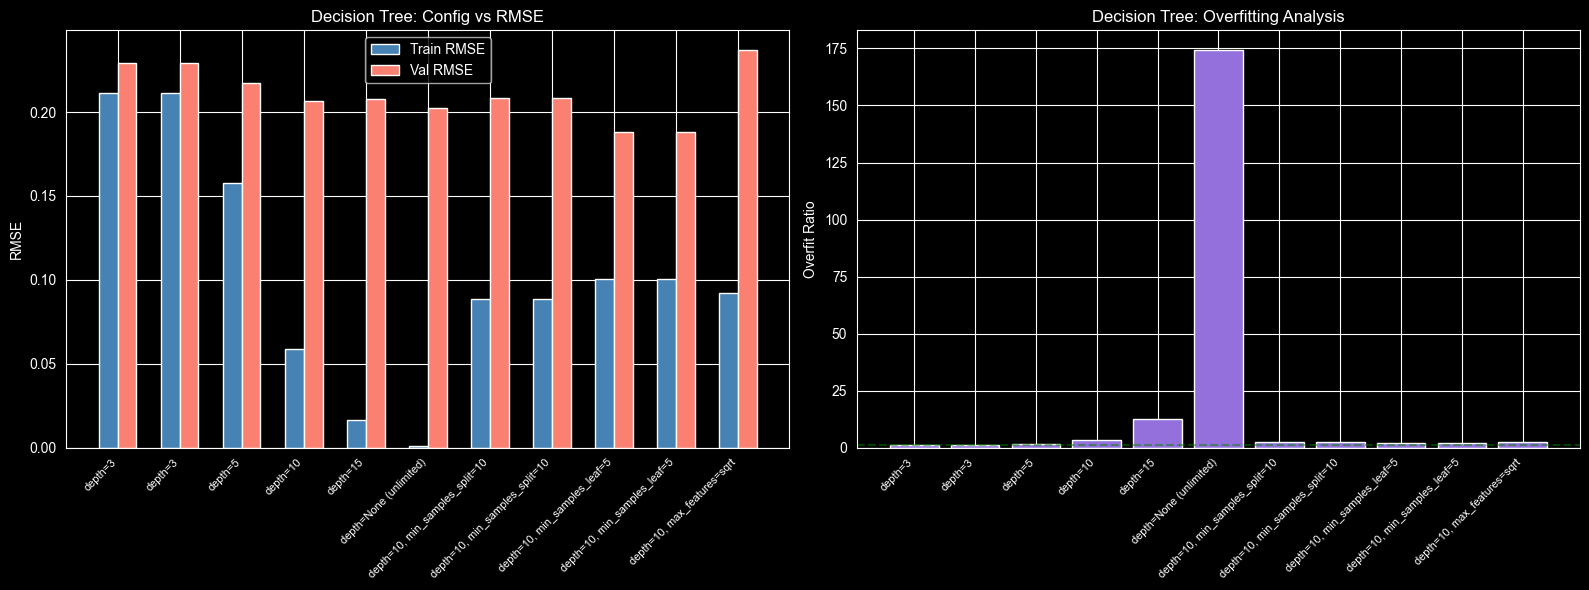


 depth=10, min_samples_leaf=5 (Val RMSE = 0.18797)


In [121]:


configs = [r['config'] for r in dt_all]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x_pos = range(len(configs))
axes[0].bar([x - 0.15 for x in x_pos], [r['train_rmse'] for r in dt_all], 0.3, label='Train RMSE', color='steelblue')
axes[0].bar([x + 0.15 for x in x_pos], [r['val_rmse'] for r in dt_all], 0.3, label='Val RMSE', color='salmon')
axes[0].set_xticks(list(x_pos))
axes[0].set_xticklabels(configs, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('RMSE')
axes[0].set_title('Decision Tree: Config vs RMSE')
axes[0].legend()

axes[1].bar(x_pos, [r['overfit_ratio'] for r in dt_all], color='mediumpurple')
axes[1].axhline(y=1.0, color='green', linestyle='--', alpha=0.5)
axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels(configs, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Overfit Ratio')
axes[1].set_title('Decision Tree: Overfitting Analysis')
plt.tight_layout()
plt.show()

best_dt = min(dt_all, key=lambda x: x['val_rmse'])
print(f"\n {best_dt['config']} (Val RMSE = {best_dt['val_rmse']:.5f})")

all_results.append({'name': f'DT_{best_dt["config"]}', 'model': best_dt['model'],
                    **{k: v for k, v in best_dt.items() if k not in ['config', 'model']}})

## 5.6 Random Forest

In [122]:
rf_all = []

In [186]:

rf_100_10_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_100_10_m = train_evaluate(rf_100_10_model, X_tr, y_tr, X_val, y_val)
print_metrics("Random Forest n=100, depth=10", rf_100_10_m)
rf_all.append({'config': 'n=100, depth=10', 'model': rf_100_10_model, **rf_100_10_m})
log_to_mlflow("RF_n100_depth10", rf_100_10_model, rf_100_10_m,
              {'model_type': 'RandomForest', 'n_estimators': 100, 'max_depth': 10},
              experiment_name="RF_n100_depth10")

  Train RMSE: 0.06065  
  Val RMSE:   0.13971 
  CV RMSE:    0.13674
  Val R²:     0.8842
  Overfit:    2.304


In [187]:

rf_200_15_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_200_15_m = train_evaluate(rf_200_15_model, X_tr, y_tr, X_val, y_val)
print_metrics("Random Forest n=200, depth=15", rf_200_15_m)
rf_all.append({'config': 'n=200, depth=15', 'model': rf_200_15_model, **rf_200_15_m})
log_to_mlflow("RF_n200_depth15", rf_200_15_model, rf_200_15_m,
              {'model_type': 'RandomForest', 'n_estimators': 200, 'max_depth': 15},
              experiment_name="RF_n200_depth15")

  Train RMSE: 0.05131  
  Val RMSE:   0.13842 
  CV RMSE:    0.13533
  Val R²:     0.8863
  Overfit:    2.698


In [188]:


rf_300_none_model = RandomForestRegressor(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
rf_300_none_m = train_evaluate(rf_300_none_model, X_tr, y_tr, X_val, y_val)
print_metrics("Random Forest n=300, depth=None", rf_300_none_m)
rf_all.append({'config': 'n=300, depth=None', 'model': rf_300_none_model, **rf_300_none_m})
log_to_mlflow("RF_n300_depthNone", rf_300_none_model, rf_300_none_m,
              {'model_type': 'RandomForest', 'n_estimators': 300, 'max_depth': 'None'},
              experiment_name="RF_n300_depthNone")

  Train RMSE: 0.05003  
  Val RMSE:   0.13759 
  CV RMSE:    0.13517
  Val R²:     0.8877
  Overfit:    2.750


In [189]:

rf_200_15_ml5_model = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_200_15_ml5_m = train_evaluate(rf_200_15_ml5_model, X_tr, y_tr, X_val, y_val)
print_metrics("Random Forest n=200, depth=15, min_leaf=5", rf_200_15_ml5_m)
rf_all.append({'config': 'n=200, depth=15, min_leaf=5', 'model': rf_200_15_ml5_model, **rf_200_15_ml5_m})
log_to_mlflow("RF_n200_depth15_min_leaf5", rf_200_15_ml5_model, rf_200_15_ml5_m,
              {'model_type': 'RandomForest', 'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 5},
              experiment_name="RF_n200_depth15_min_leaf5")

  Train RMSE: 0.09268  
  Val RMSE:   0.14273 
  CV RMSE:    0.14062
  Val R²:     0.8791
  Overfit:    1.540


In [191]:

rf_200_15_mfsqrt_model = RandomForestRegressor(n_estimators=200, max_depth=15, max_features='sqrt', random_state=42, n_jobs=-1)
rf_200_15_mfsqrt_m = train_evaluate(rf_200_15_mfsqrt_model, X_tr, y_tr, X_val, y_val)
print_metrics("Random Forest n=200, depth=15, max_feat=sqrt", rf_200_15_mfsqrt_m)
rf_all.append({'config': 'n=200, depth=15, max_feat=sqrt', 'model': rf_200_15_mfsqrt_model, **rf_200_15_mfsqrt_m})
log_to_mlflow("RF_n200_depth15_max_featsqrt", rf_200_15_mfsqrt_model, rf_200_15_mfsqrt_m,
              {'model_type': 'RandomForest', 'n_estimators': 200, 'max_depth': 15, 'max_features': 'sqrt'},
              experiment_name="RF_n200_depth15_max_featsqrt")

  Train RMSE: 0.05082  
  Val RMSE:   0.13588 
  CV RMSE:    0.13169
  Val R²:     0.8905
  Overfit:    2.674


In [192]:

rf_200_15_mf05_model = RandomForestRegressor(n_estimators=200, max_depth=15, max_features=0.5, random_state=42, n_jobs=-1)
rf_200_15_mf05_m = train_evaluate(rf_200_15_mf05_model, X_tr, y_tr, X_val, y_val)
print_metrics("Random Forest n=200, depth=15, max_feat=0.5", rf_200_15_mf05_m)
rf_all.append({'config': 'n=200, depth=15, max_feat=0.5', 'model': rf_200_15_mf05_model, **rf_200_15_mf05_m})
log_to_mlflow("RF_n200_depth15_max_feat0.5", rf_200_15_mf05_model, rf_200_15_mf05_m,
              {'model_type': 'RandomForest', 'n_estimators': 200, 'max_depth': 15, 'max_features': 0.5},
              experiment_name="RF_n200_depth15_max_feat0.5")

  Train RMSE: 0.04943  
  Val RMSE:   0.13212 
  CV RMSE:    0.13080
  Val R²:     0.8964
  Overfit:    2.673


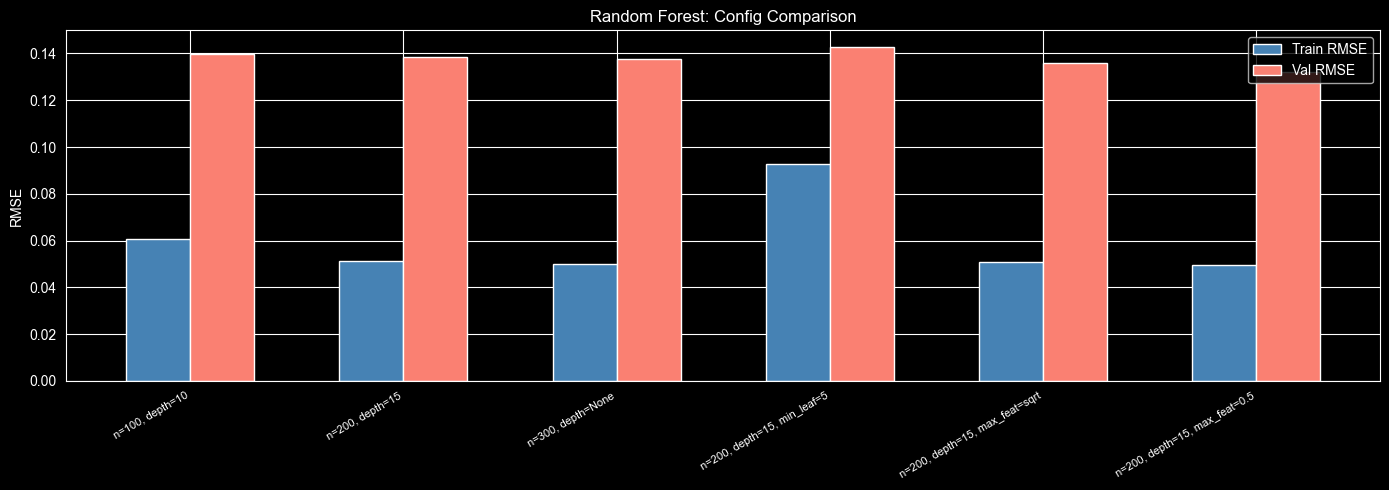


n=200, depth=15, max_feat=0.5 Val RMSE = 0.13212


In [131]:

configs = [r['config'] for r in rf_all]
fig, ax = plt.subplots(figsize=(14, 5))
x_pos = range(len(configs))
ax.bar([x - 0.15 for x in x_pos], [r['train_rmse'] for r in rf_all], 0.3, label='Train RMSE', color='steelblue')
ax.bar([x + 0.15 for x in x_pos], [r['val_rmse'] for r in rf_all], 0.3, label='Val RMSE', color='salmon')
ax.set_xticks(list(x_pos))
ax.set_xticklabels(configs, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('RMSE')
ax.set_title('Random Forest: Config Comparison')
ax.legend()
plt.tight_layout()
plt.show()

best_rf = min(rf_all, key=lambda x: x['val_rmse'])
print(f"\n{best_rf['config']} Val RMSE = {best_rf['val_rmse']:.5f}")

all_results.append({'name': f'RF_{best_rf["config"]}', 'model': best_rf['model'],
                    **{k: v for k, v in best_rf.items() if k not in ['config', 'model']}})

---
# 6. Results

In [132]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'} for r in all_results])
results_df = results_df.sort_values('val_rmse')


print("sorted by validation rmse")

print(results_df[['name', 'train_rmse', 'val_rmse', 'cv_rmse', 'val_r2', 'overfit_ratio']].to_string(index=False))

sorted by validation rmse
                            name  train_rmse  val_rmse  cv_rmse   val_r2  overfit_ratio
                 Ridge_alpha=1.0    0.106528  0.114243 0.112971 0.922578       1.072417
                 Ridge_alpha=1.0    0.106528  0.114243 0.112971 0.922578       1.072417
                 Ridge_alpha=1.0    0.106528  0.114243 0.112971 0.922578       1.072417
                 Ridge_alpha=1.0    0.106528  0.114243 0.112971 0.922578       1.072417
                LinearRegression    0.106528  0.114250 0.113003 0.922568       1.072497
                LinearRegression    0.106528  0.114250 0.113003 0.922568       1.072497
      ElasticNet_a=0.0005_l1=0.2    0.106530  0.114260 0.112880 0.922555       1.072562
      ElasticNet_a=0.0005_l1=0.2    0.106530  0.114260 0.112880 0.922555       1.072562
      ElasticNet_a=0.0005_l1=0.2    0.106530  0.114260 0.112880 0.922555       1.072562
              Lasso_alpha=0.0001    0.106530  0.114265 0.112886 0.922549       1.072604
RF_n=2

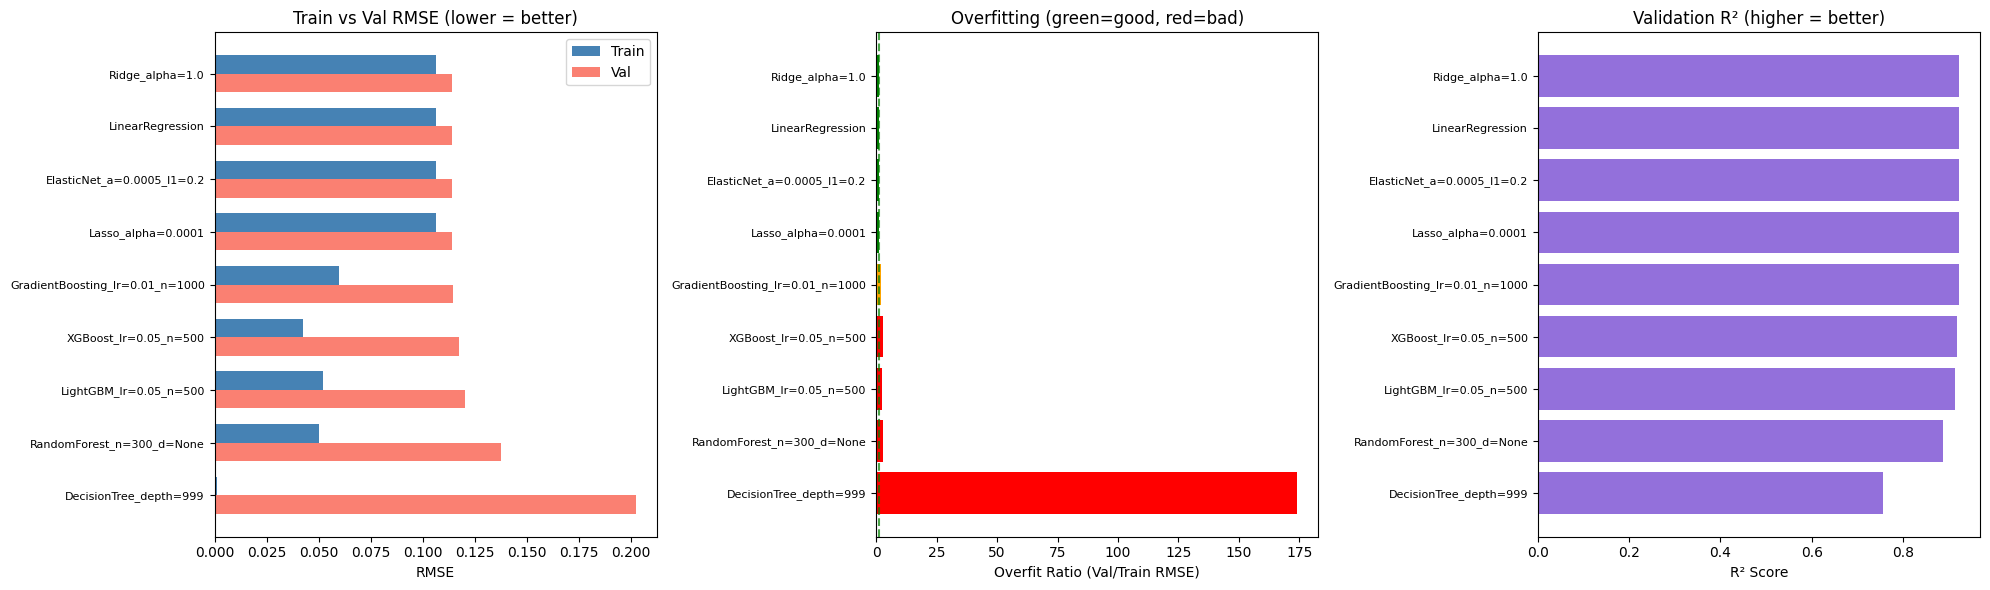

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

names = results_df['name'].values
x = np.arange(len(names))

# Plot 1: Train vs Val RMSE
width = 0.35
axes[0].barh(x - width/2, results_df['train_rmse'], width, label='Train', color='steelblue')
axes[0].barh(x + width/2, results_df['val_rmse'], width, label='Val', color='salmon')
axes[0].set_yticks(x)
axes[0].set_yticklabels(names, fontsize=8)
axes[0].set_xlabel('RMSE')
axes[0].set_title('Train vs Val RMSE (lower = better)')
axes[0].legend()
axes[0].invert_yaxis()

# Plot 2: Overfit ratio
colors = ['green' if r < 1.3 else 'orange' if r < 2 else 'red'
          for r in results_df['overfit_ratio']]
axes[1].barh(x, results_df['overfit_ratio'], color=colors)
axes[1].axvline(x=1.0, color='green', linestyle='--', alpha=0.7)
axes[1].set_yticks(x)
axes[1].set_yticklabels(names, fontsize=8)
axes[1].set_xlabel('Overfit Ratio (Val/Train RMSE)')
axes[1].set_title('Overfitting (green=good, red=bad)')
axes[1].invert_yaxis()

# Plot 3: R² score
axes[2].barh(x, results_df['val_r2'], color='mediumpurple')
axes[2].set_yticks(x)
axes[2].set_yticklabels(names, fontsize=8)
axes[2].set_xlabel('R² Score')
axes[2].set_title('Validation R² (higher = better)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

In [135]:

overfit_models = results_df[results_df['overfit_ratio'] > 2.0]
if len(overfit_models) > 0:
    print(f"\noverfitted models ")
    for _, row in overfit_models.iterrows():
        print(f"  {row['name']}:")
        print(f"    Train RMSE = {row['train_rmse']:.5f}, Val RMSE = {row['val_rmse']:.5f}")
        print(f"    Overfit ratio = {row['overfit_ratio']:.2f}")


overfitted models 
  RF_n=200, depth=15, max_feat=0.5:
    Train RMSE = 0.04943, Val RMSE = 0.13212
    Overfit ratio = 2.67
  RF_n=200, depth=15, max_feat=0.5:
    Train RMSE = 0.04943, Val RMSE = 0.13212
    Overfit ratio = 2.67
  RF_n=200, depth=15, max_feat=0.5:
    Train RMSE = 0.04943, Val RMSE = 0.13212
    Overfit ratio = 2.67


In [137]:
best_row = results_df.iloc[0]
best_model_obj = [r['model'] for r in all_results if r['name'] == best_row['name']][0]

## 6.2 Residual Analysis (Best Model)

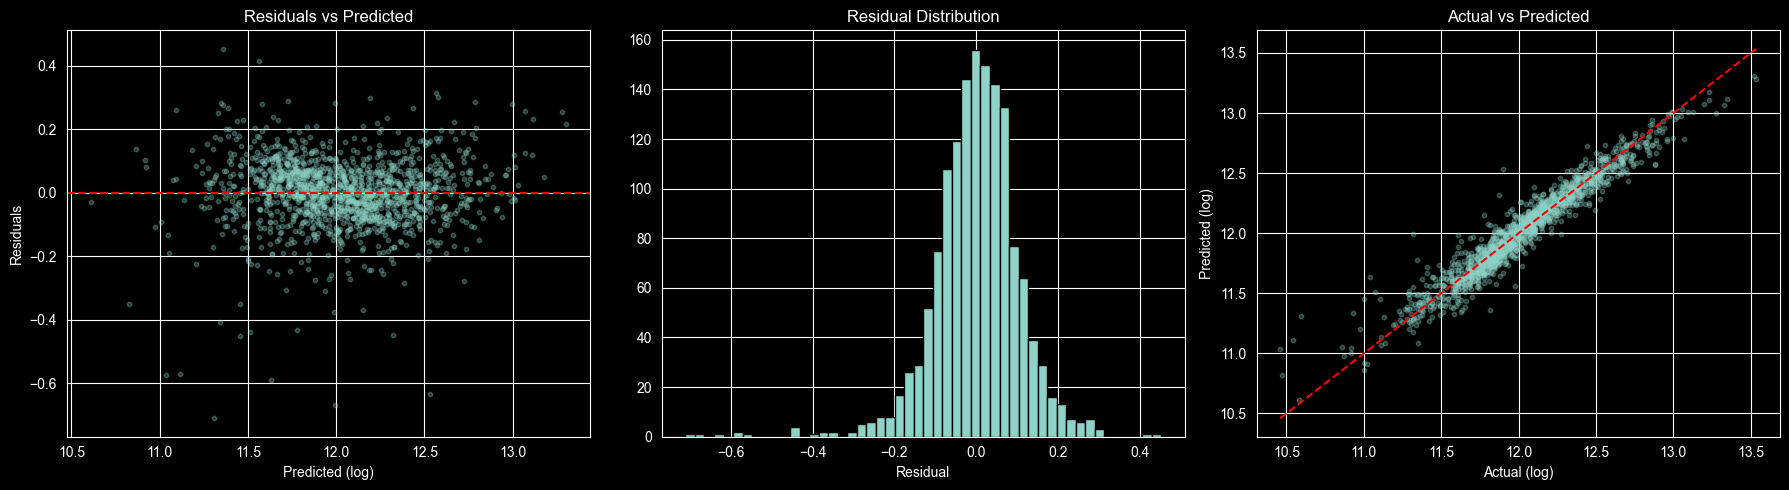

Residual mean:  -0.000000
Residual std:   0.10747


In [139]:
needs_scaling = 'Linear' in best_row['name'] or 'Ridge' in best_row['name'] or \
                'Lasso' in best_row['name'] or 'Elastic' in best_row['name']

if needs_scaling:
    X_full_scaled = pd.DataFrame(scaler.fit_transform(X_train_final),
                                 columns=X_train_final.columns, index=X_train_final.index)
    best_model_obj.fit(X_full_scaled, y_log)
    preds_log = best_model_obj.predict(X_full_scaled)
else:
    best_model_obj.fit(X_train_final, y_log)
    preds_log = best_model_obj.predict(X_train_final)

residuals = y_log.values - preds_log

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(preds_log, residuals, alpha=0.3, s=10)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted (log)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')

axes[2].scatter(y_log, preds_log, alpha=0.3, s=10)
axes[2].plot([y_log.min(), y_log.max()], [y_log.min(), y_log.max()], 'r--')
axes[2].set_xlabel('Actual (log)')
axes[2].set_ylabel('Predicted (log)')
axes[2].set_title('Actual vs Predicted')

plt.tight_layout()
plt.show()

print(f"Residual mean:  {residuals.mean():.6f}")
print(f"Residual std:   {residuals.std():.5f}")

## 6.3 Register Best Model to MLflow Model Registry

In [143]:
if needs_scaling:
    X_full_scaled = pd.DataFrame(scaler.fit_transform(X_train_final),
                                 columns=X_train_final.columns, index=X_train_final.index)
    best_model_obj.fit(X_full_scaled, y_log)
else:
    best_model_obj.fit(X_train_final, y_log)

full_cv = cross_val_score(best_model_obj, X_train_final, y_log,
                          cv=kfold, scoring='neg_mean_squared_error')
full_cv_rmse = np.sqrt(-full_cv).mean()

mlflow.set_experiment("Final_Model")
with mlflow.start_run(run_name="BEST_" + best_row['name']):
    mlflow.log_param("model_type", best_row['name'])
    mlflow.log_param("feature_selection", best_fs_name)
    mlflow.log_param("trained_on", "full_train_set")
    mlflow.log_param("n_features", X_train_final.shape[1])

    mlflow.log_metric("val_RMSE", best_row['val_rmse'])
    mlflow.log_metric("val_R2", best_row['val_r2'])
    mlflow.log_metric("cv_RMSE", full_cv_rmse)
    mlflow.log_metric("overfit_ratio", best_row['overfit_ratio'])

    mlflow.sklearn.log_model(
        best_model_obj, "model",
        registered_model_name="HousePrices_Final"
    )

print(f"Registered '{best_row['name']}' to Model Registry as 'HousePrices_Final'")
print(f"Full-data CV RMSE: {full_cv_rmse:.5f}")

2026/04/13 21:43:21 INFO mlflow.tracking.fluent: Experiment with name 'Final_Model' does not exist. Creating a new experiment.
2026/04/13 21:43:21 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT

🏃 View run BEST_Ridge_alpha=1.0 at: https://dagshub.com/rkvit23/ML-HW1.mlflow/#/experiments/49/runs/6ae2121bbe5a42429a8aa0d3e1da80f3
🧪 View experiment at: https://dagshub.com/rkvit23/ML-HW1.mlflow/#/experiments/49
Registered 'Ridge_alpha=1.0' to Model Registry as 'HousePrices_Final'
Full-data CV RMSE: 0.11244


## 6.4 Save Preprocessing Artifacts for Inference

In [144]:
import pickle

artifacts = {
    'mv_handler': mv_handler,
    'feat_eng': feat_eng,
    'nom_encoder': nom_encoder,
    'corr_filter': corr_filter,
    'scaler': scaler,
    'best_fs_name': best_fs_name,
    'important_features': important_features if best_fs_name == 'RF Importance Filter' else None,
    'rfe_features': rfe_features if best_fs_name == 'RFE (50 features)' else None,
    'mi_features': mi_features if best_fs_name == 'Mutual Information' else None,
    'perm_features': perm_features if best_fs_name == 'Permutation Importance' else None,
    'skewed_features': skewed_features,
    'needs_scaling': needs_scaling,
}

with open('preprocessing_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Saved preprocessing artifacts to preprocessing_artifacts.pkl")
print(f"Best feature selection method: {best_fs_name}")
print(f"Model needs scaling: {needs_scaling}")

Saved preprocessing artifacts to preprocessing_artifacts.pkl
Best feature selection method: Permutation Importance
Model needs scaling: True
